In [7]:
import argparse
import sys
import os
import time
import datetime
import ast
from collections import Counter
from pathlib import Path
import hydra
import dill as pkl

import numpy as np
import torch

# Ensure local src/ is importable
sys.path.insert(0, str(Path(os.getcwd()).parent / "src"))

from my_genQC.inference.eval_metrics import UnitaryFrobeniusNorm, UnitaryInfidelityNorm
from my_genQC.inference.evaluation_helper import get_unitaries, get_srvs
from my_genQC.inference.sampling import generate_compilation_tensors, generate_tensors, decode_tensors_to_backend
from my_genQC.pipeline.diffusion_pipeline import DiffusionPipeline
from my_genQC.platform.simulation import Simulator, CircuitBackendType
from my_genQC.platform.tokenizer.circuits_tokenizer import CircuitTokenizer
from my_genQC.utils.misc_utils import infer_torch_device, get_entanglement_bins
from my_genQC.dataset import circuits_dataset
from my_genQC.models.config_model import ConfigModel
from my_genQC.utils.config_loader import load_config, store_tensor, load_tensor

from quantum_diffusion.data.dataset import DatasetLoader
from quantum_diffusion.evaluation.evaluator import SRVEvaluator

## Evaluation

In [3]:
# Config loading
with hydra.initialize(version_base=None, config_path="../conf"):
    cfg = hydra.compose(config_name="config.yaml", overrides=["evaluation=remote_model"])
    cfg = cfg["evaluation"]

In [4]:
def evaluate_remote_model(num_qubits: int, tensor_out_file, config):
    config.dataset = f"../datasets/paper_qiskit/srv_{num_qubits}q_dataset"
    config.wandb.run_name = f"{num_qubits}q_remote_model_evaluation"
    evaluator = SRVEvaluator(config=cfg)

    tensors_out = load_tensor(f"../scripts/inference/{tensor_out_file}", device="cuda")

    decoded_circuits = evaluator.decode_tensors(tensors_out)
    valid_indices, target_srvs, predicted_srvs = evaluator.validate_and_calculate_srvs(decoded_circuits)
    srv_exact_match_rate, acc_per_entanglement = evaluator.calculate_metrics(target_srvs, predicted_srvs)

    return evaluator, decoded_circuits, valid_indices, target_srvs, predicted_srvs, srv_exact_match_rate, acc_per_entanglement

### Quditkit dataset

In [ ]:
q3_evaluator, q3_decoded_circuits, q3_valid_indices, q3_target_srvs, q3_predicted_srvs, q3_srv_exact_match_rate, q3_acc_per_entanglement = evaluate_remote_model(3, "3q_163327_samples.pt", cfg)

In [ ]:
q4_evaluator, q4_decoded_circuits, q4_valid_indices, q4_target_srvs, q4_predicted_srvs, q4_srv_exact_match_rate, q4_acc_per_entanglement = evaluate_remote_model(4, "4q_281970_samples.pt", cfg)

In [ ]:
q5_evaluator, q5_decoded_circuits, q5_valid_indices, q5_target_srvs, q5_predicted_srvs, q5_srv_exact_match_rate, q5_acc_per_entanglement = evaluate_remote_model(5, "5q_497496_samples.pt", cfg)

In [ ]:
q6_evaluator, q6_decoded_circuits, q6_valid_indices, q6_target_srvs, q6_predicted_srvs, q6_srv_exact_match_rate, q6_acc_per_entanglement = evaluate_remote_model(6, "6q_499926_samples.pt", cfg)

In [ ]:
q7_evaluator, q7_decoded_circuits, q7_valid_indices, q7_target_srvs, q7_predicted_srvs, q7_srv_exact_match_rate, q7_acc_per_entanglement = evaluate_remote_model(7, "7q_499968_samples.pt", cfg)

In [ ]:
q8_evaluator, q8_decoded_circuits, q8_valid_indices, q8_target_srvs, q8_predicted_srvs, q8_srv_exact_match_rate, q8_acc_per_entanglement = evaluate_remote_model(8, "8q_599936_samples.pt", cfg)

## Visualization

### Data loading

In [58]:
results_dir = "./results/quditkit_dataset"

results_dict = {num_qubits: {"predicted_srvs": None, "target_srvs": None, "acc_per_entanglement": None, "srv_exact_match_rate": None} for num_qubits in range(3, 9)}

for num_qubits, num_qubits_dir in enumerate(sorted(os.listdir(results_dir))):
    
    dir_path = os.path.join(results_dir, num_qubits_dir)

    for file in os.listdir(dir_path):
        file_path = os.path.join(dir_path, file)

        for key in results_dict[num_qubits + 3].keys():
            if key in file and str(num_qubits + 3) in file:
                if ".pt" in file:
                    data = load_tensor(file_path, device="cpu")
                elif ".pkl" in file:
                    with open(file_path, "rb") as f:
                        data = pkl.load(f)

                results_dict[num_qubits + 3][key] = data
                continue

[INFO]: Loading tensor from `./results/quditkit_dataset/q3/q3_target_srvs.pt` onto device: cpu.
[INFO]: Loading tensor from `./results/quditkit_dataset/q3/q3_predicted_srvs.pt` onto device: cpu.
[INFO]: Loading tensor from `./results/quditkit_dataset/q4/q4_target_srvs.pt` onto device: cpu.
[INFO]: Loading tensor from `./results/quditkit_dataset/q4/q4_predicted_srvs.pt` onto device: cpu.
[INFO]: Loading tensor from `./results/quditkit_dataset/q5/q5_predicted_srvs.pt` onto device: cpu.
[INFO]: Loading tensor from `./results/quditkit_dataset/q5/q5_target_srvs.pt` onto device: cpu.
[INFO]: Loading tensor from `./results/quditkit_dataset/q6/q6_target_srvs.pt` onto device: cpu.
[INFO]: Loading tensor from `./results/quditkit_dataset/q6/q6_predicted_srvs.pt` onto device: cpu.
[INFO]: Loading tensor from `./results/quditkit_dataset/q7/q7_target_srvs.pt` onto device: cpu.
[INFO]: Loading tensor from `./results/quditkit_dataset/q7/q7_predicted_srvs.pt` onto device: cpu.
[INFO]: Loading tensor fr

In [67]:
from collections import defaultdict
import numpy as np

def accuracy_per_entangled_macro_srv(target_srvs, predicted_srvs):
    
    # Collect per-SRV counts
    total_per_srv = defaultdict(int)
    correct_per_srv = defaultdict(int)

    # Convert SRVs to hashable keys (tuple of ints)
    for target, predicted in zip(target_srvs, predicted_srvs):
        target_key = tuple(np.asarray(target, dtype=int).tolist())
        pred_key   = tuple(np.asarray(predicted, dtype=int).tolist())

        total_per_srv[target_key] += 1
        if target_key == pred_key:
            correct_per_srv[target_key] += 1

    # Compute per-SRV accuracies and group them by n_entangled
    accs_by_n_ent = defaultdict(list)
    for srv_key, n_total in total_per_srv.items():
        n_correct = correct_per_srv.get(srv_key, 0)
        acc_srv = n_correct / n_total if n_total else 0.0

        n_entangled = sum(1 for v in srv_key if v == 2)
        accs_by_n_ent[n_entangled].append(acc_srv)

    # Macro average (mean over SRVs) for each n_entangled
    acc_per_entangled = {}
    for n_entangled, acc_list in accs_by_n_ent.items():
        acc_per_entangled[n_entangled] = float(np.mean(acc_list)) if acc_list else 0.0

    return acc_per_entangled

In [68]:
for num_qubits in results_dict.keys():
    current_results = results_dict[num_qubits]
    macro_acc = accuracy_per_entangled_macro_srv(current_results["target_srvs"], current_results["predicted_srvs"])
    results_dict[num_qubits]["macro_acc"] = macro_acc

### Visualization

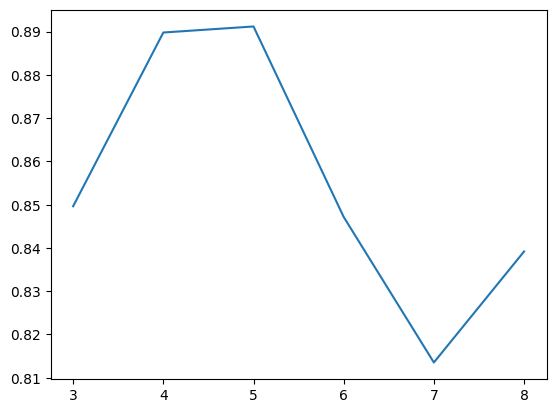

In [80]:
srv_exact_match_rates = [res["srv_exact_match_rate"] for res in results_dict.values()]
plt.plot(range(3, 9), srv_exact_match_rates)

In [70]:
import matplotlib.pyplot as plt
import matplotlib as mpl

def plot_acc_by_qubits(q3_acc_per_entanglement, q4_acc_per_entanglement, q5_acc_per_entanglement, q6_acc_per_entanglement, q7_acc_per_entanglement, q8_acc_per_entanglement):
    # Map qubits -> your dicts (keys=x, values=y)
    acc_by_qubits = {
        3: q3_acc_per_entanglement,
        4: q4_acc_per_entanglement,
        5: q5_acc_per_entanglement,
        6: q6_acc_per_entanglement,
        7: q7_acc_per_entanglement,
        8: q8_acc_per_entanglement,
    }
    
    fig, ax = plt.subplots(figsize=(5, 3.6), dpi=150)
    
    # ---- Discrete colormap for integer qubits (stepped colorbar) ----
    qubits = np.array(sorted(acc_by_qubits.keys()))
    cmap = plt.get_cmap("Oranges", len(qubits)) # quantized version of Oranges
    
    # boundaries between integers -> discrete steps
    bounds = np.arange(qubits.min() - 0.5, qubits.max() + 1.5, 1.0)
    norm = mpl.colors.BoundaryNorm(bounds, cmap.N)
    
    for q, acc in acc_by_qubits.items():
        # Ensure x is sorted (dict order may not match numeric order)
        xs = sorted(acc.keys())
        ys = [acc[x] for x in xs]
    
        ax.plot(
            xs, ys,
            marker="o", markersize=3,
            # linewidth=2,
            color=cmap(norm(q)),
            alpha=0.95,
        )
    
    # ---- Stepped colorbar labeled "Qubits" ----
    sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, pad=0.02, ticks=qubits, boundaries=bounds)
    cbar.set_label("Qubits")
    
    # Styling to resemble the example
    ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.35)
    
    ax.set_ylabel("Accuracy")
    ax.set_xlabel("Entangled qubits")
    
    plt.tight_layout()
    plt.show()

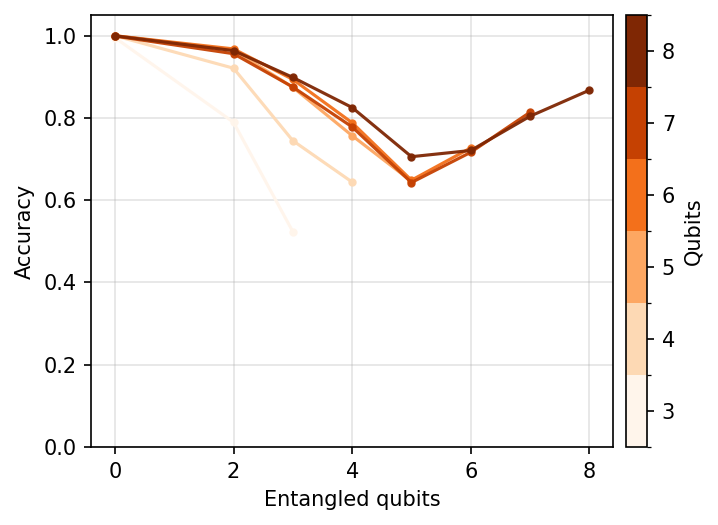

In [71]:
plot_acc_by_qubits(results_dict[3]["acc_per_entanglement"], results_dict[4]["acc_per_entanglement"], results_dict[5]["acc_per_entanglement"], results_dict[6]["acc_per_entanglement"], results_dict[7]["acc_per_entanglement"], results_dict[8]["acc_per_entanglement"])

#### Reference plot from paper

<img src="references/acc_vs_entangled_qubits.png" width="700" height="700"> 

In [73]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter, defaultdict

def plot_srv_distributions(
    target_srvs,
    predicted_srvs=None,
    num_qubits=None,
    topk_srvs=20,
    figsize=(14, 10),
    title_prefix="",
):
    """
    Plots distribution diagnostics for SRVs and number of entangled qubits.

    Args:
        target_srvs: iterable of array-like SRVs (shape [num_qubits], entries typically 1/2).
        predicted_srvs: optional iterable of predicted SRVs aligned with target_srvs.
        num_qubits: optional int; inferred from first SRV if None.
        topk_srvs: number of most common SRVs to display in the SRV frequency bar chart.
        figsize: matplotlib figure size.
        title_prefix: optional string prefix for plot titles.

    Notes:
        - "n_entangled" is computed as count of entries == 2 in the SRV (paper setup) [file:1].
        - SRVs are treated as tuples of ints for counting.
    """
    target_srvs = [tuple(np.asarray(s, dtype=int).tolist()) for s in target_srvs]
    if len(target_srvs) == 0:
        raise ValueError("target_srvs is empty")

    if num_qubits is None:
        num_qubits = len(target_srvs[0])

    if any(len(s) != num_qubits for s in target_srvs):
        raise ValueError("Not all target SRVs have the same length")

    pred = None
    if predicted_srvs is not None:
        predicted_srvs = [tuple(np.asarray(s, dtype=int).tolist()) for s in predicted_srvs]
        if len(predicted_srvs) != len(target_srvs):
            raise ValueError("predicted_srvs must have same length as target_srvs")
        if any(len(s) != num_qubits for s in predicted_srvs):
            raise ValueError("Not all predicted SRVs have the same length")
        pred = predicted_srvs

    def n_entangled(srv):
        return sum(1 for v in srv if v == 2)

    # ---- Counts (targets) ----
    tgt_srv_counts = Counter(target_srvs)
    tgt_ent_counts = Counter(n_entangled(s) for s in target_srvs)

    # Per-qubit marginal: P(SRV_i == 2)
    tgt_ent_per_qubit = np.zeros(num_qubits, dtype=float)
    for srv in target_srvs:
        tgt_ent_per_qubit += (np.asarray(srv) == 2).astype(float)
    tgt_ent_per_qubit /= len(target_srvs)

    # ---- Counts (predictions, optional) ----
    if pred is not None:
        pred_srv_counts = Counter(pred)
        pred_ent_counts = Counter(n_entangled(s) for s in pred)

        pred_ent_per_qubit = np.zeros(num_qubits, dtype=float)
        for srv in pred:
            pred_ent_per_qubit += (np.asarray(srv) == 2).astype(float)
        pred_ent_per_qubit /= len(pred)

        # Error analysis by target entangled count
        err_by_ent = defaultdict(lambda: {"n": 0, "err": 0})
        for t, p in zip(target_srvs, pred):
            k = n_entangled(t)
            err_by_ent[k]["n"] += 1
            err_by_ent[k]["err"] += int(t != p)

    # ---- Plotting ----
    fig, axes = plt.subplots(2, 2, figsize=figsize)
    ax00, ax01, ax10, ax11 = axes.ravel()

    # (0,0) Distribution of # entangled qubits
    xs = list(range(num_qubits + 1))
    tgt_y = [tgt_ent_counts.get(x, 0) for x in xs]
    ax00.bar(xs, tgt_y, alpha=0.8, label="Target")
    if pred is not None:
        pred_y = [pred_ent_counts.get(x, 0) for x in xs]
        ax00.bar(xs, pred_y, alpha=0.5, label="Predicted")
    ax00.set_title(f"{title_prefix}# entangled qubits distribution")
    ax00.set_xlabel("# entangled qubits (count of '2' in SRV)")
    ax00.set_ylabel("Count")
    ax00.set_xticks(xs)
    ax00.legend()

    # (0,1) Top-K SRVs frequency (targets; optionally overlay predictions)
    top_tgt = tgt_srv_counts.most_common(topk_srvs)
    labels = [str(srv) for srv, _ in top_tgt]
    tgt_vals = [c for _, c in top_tgt]
    x = np.arange(len(labels))
    ax01.bar(x, tgt_vals, alpha=0.8, label="Target")
    if pred is not None:
        pred_vals = [pred_srv_counts.get(srv, 0) for srv, _ in top_tgt]
        ax01.bar(x, pred_vals, alpha=0.5, label="Predicted (same SRVs)")
    ax01.set_title(f"{title_prefix}Top-{topk_srvs} target SRVs")
    ax01.set_xlabel("SRV (as tuple)")
    ax01.set_ylabel("Count")
    ax01.set_xticks(x)
    ax01.set_xticklabels(labels, rotation=75, ha="right")
    ax01.legend()

    # (1,0) Per-qubit entanglement marginal: P(SRV_i == 2)
    qx = np.arange(num_qubits)
    ax10.plot(qx, tgt_ent_per_qubit, marker="o", label="Target")
    if pred is not None:
        ax10.plot(qx, pred_ent_per_qubit, marker="o", label="Predicted")
    ax10.set_ylim(0, 1)
    ax10.set_title(f"{title_prefix}Per-qubit entangled marginal")
    ax10.set_xlabel("Qubit index")
    ax10.set_ylabel("P(SRV[i] == 2)")
    ax10.set_xticks(qx)
    ax10.legend()

    # (1,1) Error rate vs target # entangled qubits (optional)
    if pred is None:
        ax11.axis("off")
        ax11.text(0.0, 0.5, "Provide predicted_srvs to plot error breakdown.",
                  fontsize=12)
    else:
        err_x = sorted(err_by_ent.keys())
        err_rate = [
            (err_by_ent[k]["err"] / err_by_ent[k]["n"]) if err_by_ent[k]["n"] else 0.0
            for k in err_x
        ]
        ax11.plot(err_x, err_rate, marker="o")
        ax11.set_ylim(0, 1)
        ax11.set_title(f"{title_prefix}Error rate vs target # entangled")
        ax11.set_xlabel("Target # entangled qubits")
        ax11.set_ylabel("Error rate (target != predicted)")
        ax11.set_xticks(xs)

    plt.tight_layout()
    plt.show()

    # Also return raw counts for programmatic inspection
    out = {
        "num_qubits": num_qubits,
        "target_srv_counts": tgt_srv_counts,
        "target_entangled_count": tgt_ent_counts,
        "target_entangled_per_qubit": tgt_ent_per_qubit,
    }
    if pred is not None:
        out.update({
            "pred_srv_counts": pred_srv_counts,
            "pred_entangled_count": pred_ent_counts,
            "pred_entangled_per_qubit": pred_ent_per_qubit,
            "error_by_target_entangled": dict(err_by_ent),
        })
    # return out

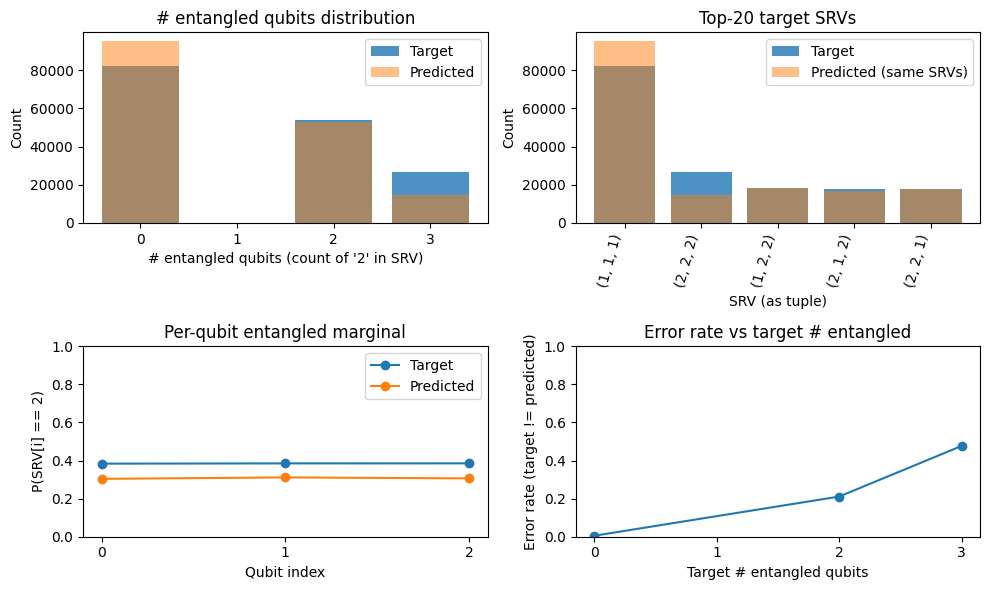

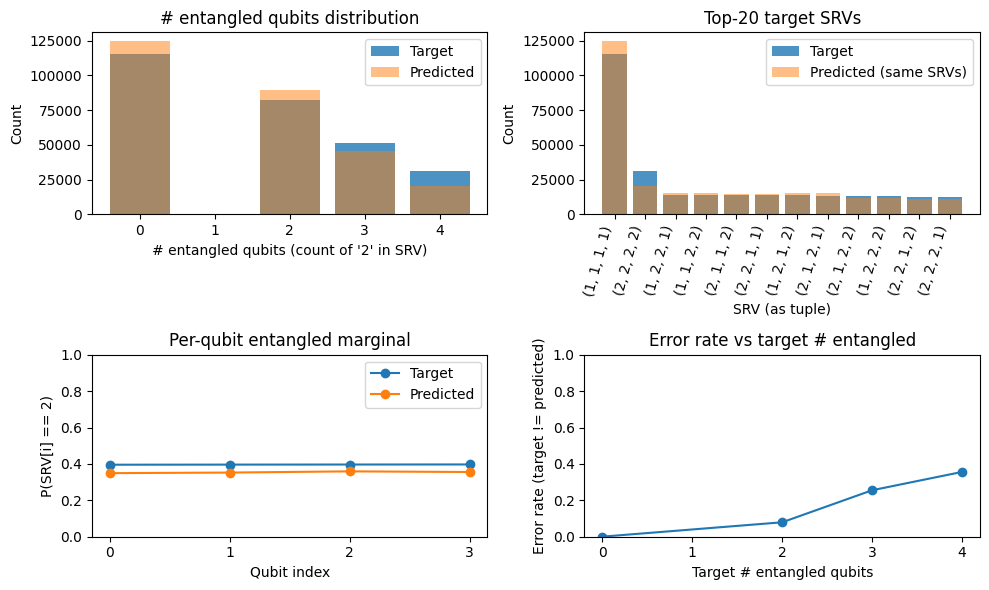

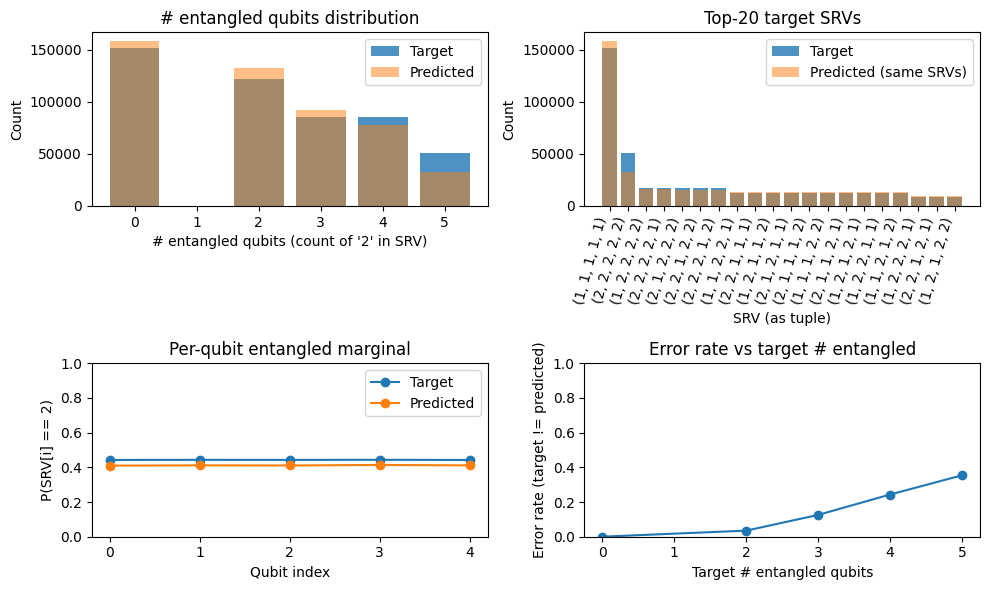

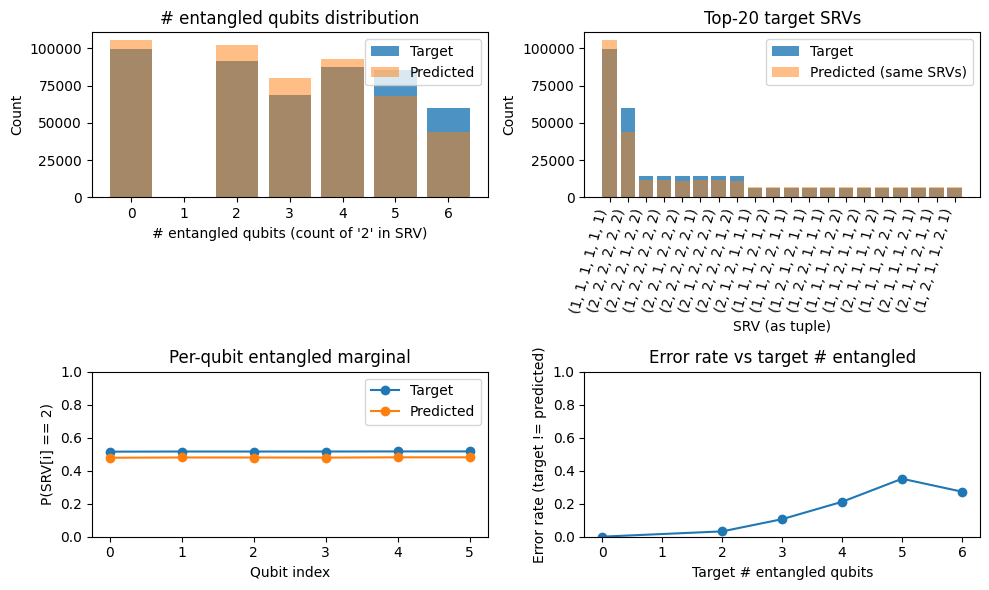

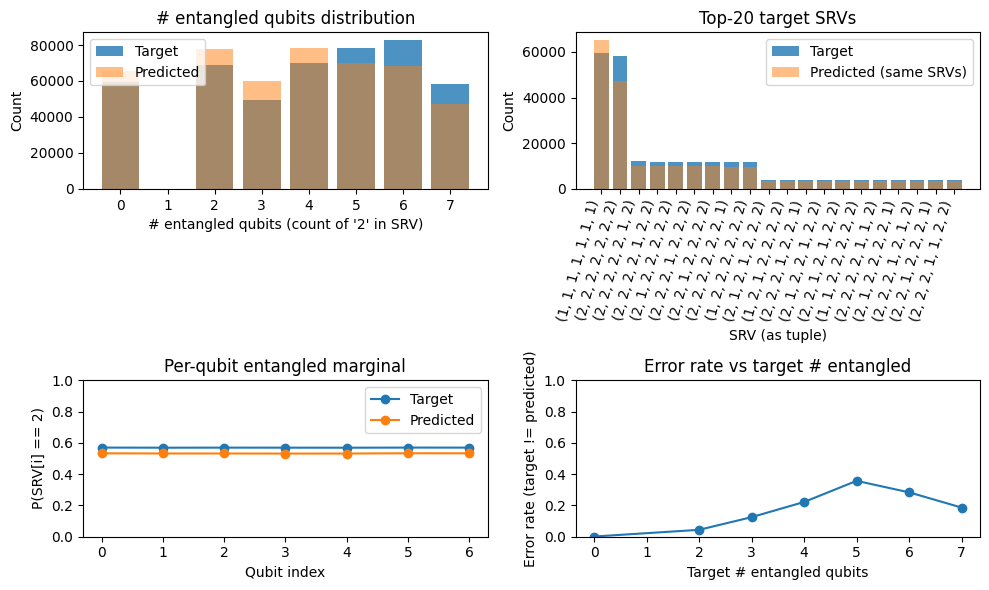

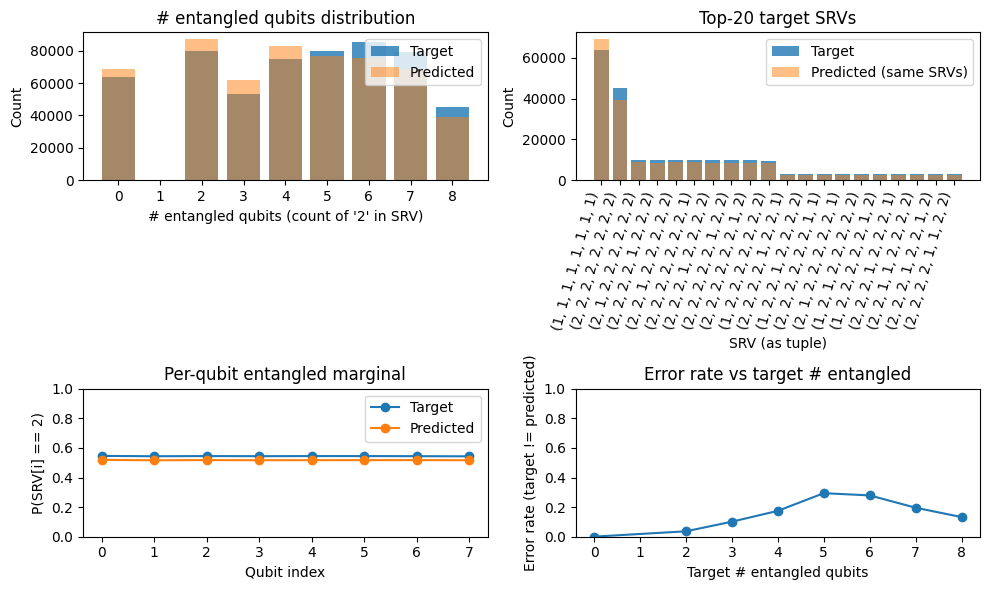

In [77]:
for key in results_dict.keys():
    plot_srv_distributions(results_dict[key]["target_srvs"], results_dict[key]["predicted_srvs"], figsize=(10, 6))

#### Possible reasons for differences
- Paper: only 8192 samples used, here over 1 million samples used
- Paper: max gates for inference fixed to 16, here no max gates set (so defaults to 52)

### Data saving

In [ ]:
import dill as pkl

for n_qubits, q_results in enumerate([[q3_valid_indices, q3_target_srvs, q3_predicted_srvs, q3_srv_exact_match_rate, q3_acc_per_entanglement],
                                      [q4_valid_indices, q4_target_srvs, q4_predicted_srvs, q4_srv_exact_match_rate, q4_acc_per_entanglement],
                                      [q5_valid_indices, q5_target_srvs, q5_predicted_srvs, q5_srv_exact_match_rate, q5_acc_per_entanglement],
                                      [q6_valid_indices, q6_target_srvs, q6_predicted_srvs, q6_srv_exact_match_rate, q6_acc_per_entanglement],
                                      [q7_valid_indices, q7_target_srvs, q7_predicted_srvs, q7_srv_exact_match_rate, q7_acc_per_entanglement],
                                      [q8_valid_indices, q8_target_srvs, q8_predicted_srvs, q8_srv_exact_match_rate, q8_acc_per_entanglement]]):

    path = f"./results/quditkit_dataset/q{n_qubits + 3}"
    os.makedirs(path, exist_ok=True)

    with open(os.path.join(path, f"q{n_qubits + 3}_valid_indices.pkl"), "wb") as f:
        pkl.dump(q_results[0], f)

    store_tensor(q_results[1], os.path.join(path, f"q{n_qubits + 3}_target_srvs.pt"))
    store_tensor(q_results[2], os.path.join(path, f"q{n_qubits + 3}_predicted_srvs.pt"))

    with open(os.path.join(path, f"q{n_qubits + 3}_srv_exact_match_rate.pkl"), "wb") as f:
        pkl.dump(q_results[3], f)

    with open(os.path.join(path, f"q{n_qubits + 3}_acc_per_entanglement.pkl"), "wb") as f:
        pkl.dump(q_results[4], f)
